# 04-b  Fatigue Connectome Baselines — Hardening Audit

**Purpose:** Adversarial analyses that challenge the baseline findings
before any fatigue-related connectomic signal can be claimed.
This notebook is the **technical appendix** to `04_a`.
The two notebooks share a single authoritative verdict: **INDETERMINATE**.

| # | Analysis | Target | Estimand |
|---|----------|--------|----------|
| 1 | Max-permutation correction (7 channels) | D + E | Within-fold PCA — same as main run |
| 2 | Holm / BH corrections on main-run *p*-values | D + E | Within-fold PCA (main run) |
| 3 | Incremental value over metadata | D only | Within-fold PCA |
| 4 | Sex-matched subsampling (females) | D only | Within-fold PCA / LOOCV |
| 5 | Metadata decomposition (Age / Sex / Age+Sex) | D only | Within-fold CV |
| 6 | Power / precision analysis | D only | Bootstrap approximation |

> **Estimand note:** All AUCs and p-values in this notebook use
> **within-fold PCA** — the same procedure as the main-run pipeline in
> `04_a`.  Residualization, scaling, and PCA are each fitted on the
> training fold only.  This ensures the max-perm corrected p-values refer
> to the same estimand as the BH/Holm corrections.


In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200,
                      "font.size": 10, "axes.titlesize": 12})

import sys
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

OUT = PROJECT_ROOT / "results" / "fatigue_connectome_baselines"
FIG = OUT / "Figures"; FIG.mkdir(exist_ok=True)

def _load_json(name):
    p = OUT / "Tables" / name
    return json.loads(p.read_text()) if p.exists() else {}


---
## §1  Max-permutation correction across 7 channels

For each of 1 000 permuted label vectors, the **full within-fold pipeline**
(residualization -> StandardScaler -> PCA -> LogisticRegression) is trained
on all 7 channels and the **maximum AUC** across channels is recorded.
The corrected *p*-value = fraction of null maxima >= observed best AUC.

**Estimand consistency:** Because PCA is fitted on the *training fold*
only (not globally), the observed AUCs here match those in the BH/Holm
correction table in §2. The max-perm corrected p-value therefore tests
the same pipeline that produced the AUCs in the BH table.

> The label-free steps (residualization, scaling, PCA) are precomputed
> per fold once and only LogisticRegression is re-fitted per permutation,
> since it is the only label-dependent step. This makes the test
> computationally tractable while preserving exact estimand consistency.

**Monte Carlo precision note (Target D resid, B = 1000):**
For corrected p = 0.027972, the binomial approximation gives
SE(p) ~ sqrt(p(1-p)/B) = 0.0052 and approximate 95% MC CI [0.0178, 0.0382].
This CI stays below 0.05 in the current run.

In [2]:
mp_d = _load_json("hardening_D_max_perm.json")
mp_e = _load_json("hardening_E_max_perm.json")

null_d = np.load(OUT / "Tables" / "hardening_D_null_distributions.npz")
null_e = np.load(OUT / "Tables" / "hardening_E_null_distributions.npz")

estimand_label = mp_d.get("estimand", "within_fold_pca")

# Summary table — AUCs now match the BH table (same within-fold estimand)
rows = []
for tgt, mp in [("D", mp_d), ("E", mp_e)]:
    for cond in ["raw", "resid"]:
        key_best = f"best_{cond}_ch"
        key_auc  = f"best_{cond}_auc"
        rows.append(dict(
            Target=tgt, Condition=cond,
            Best_Channel=mp.get(key_best, "—"),
            AUC_withinFoldPCA=mp.get(key_auc, "—"),
            Corrected_p=mp.get(f"corrected_p_{cond}", "—"),
        ))
df_mp = pd.DataFrame(rows)
print(f"Estimand: {estimand_label}")
print(df_mp.to_string(index=False))
print()

# Monte Carlo precision for the key corrected p-value in Target D residualized.
p_d = float(mp_d.get("corrected_p_resid", np.nan))
B = 1000
if np.isfinite(p_d):
    se_mc = np.sqrt(p_d * (1 - p_d) / B)
    ci_lo = max(0.0, p_d - 1.96 * se_mc)
    ci_hi = min(1.0, p_d + 1.96 * se_mc)
    crosses = "crosses" if (ci_lo <= 0.05 <= ci_hi) else "does not cross"
    print(
        f"Target D resid MC precision: p={p_d:.6f}, SE={se_mc:.5f}, "
        f"approx95%MC CI=[{ci_lo:.4f}, {ci_hi:.4f}] -> {crosses} 0.05"
    )
print("Criterion: corrected_p < 0.05 required for family-level omnibus evidence.")

Estimand: within_fold_pca
Target Condition  Best_Channel  AUC_withinFoldPCA  Corrected_p
     D       raw             2             0.7227     0.032967
     D     resid             3             0.7284     0.027972
     E       raw             5             0.6846     0.018981
     E     resid             5             0.7073     0.008991

Target D resid MC precision: p=0.027972, SE=0.00521, approx95%MC CI=[0.0178, 0.0382] -> does not cross 0.05
Criterion: corrected_p < 0.05 required for family-level omnibus evidence.


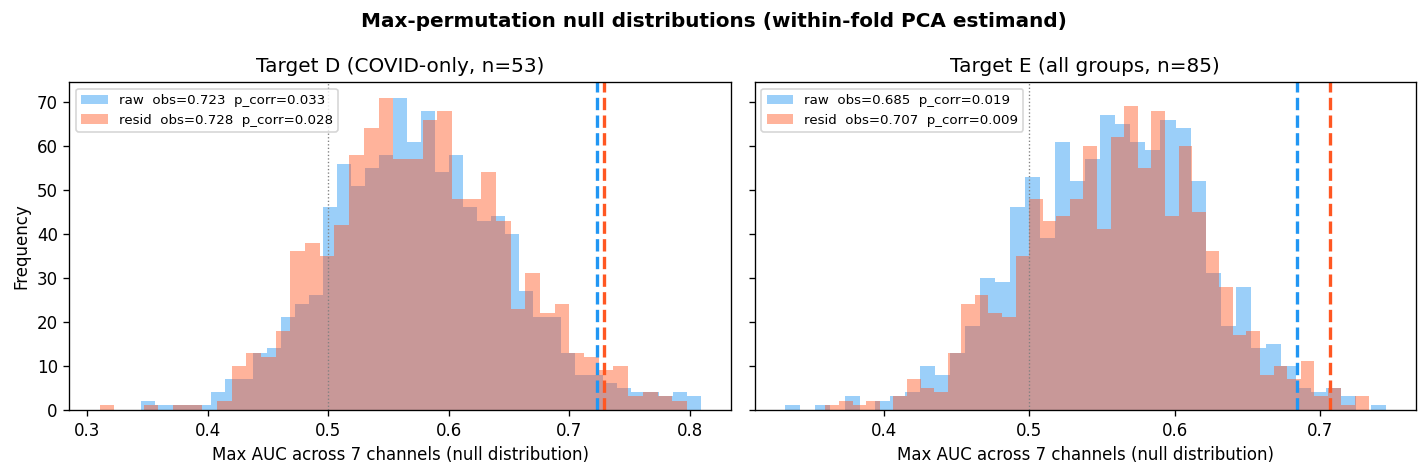

Fig 6 saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, tgt, null, mp, label in [
    (axes[0], "D", null_d, mp_d, "Target D (COVID-only, n=53)"),
    (axes[1], "E", null_e, mp_e, "Target E (all groups, n=85)"),
]:
    for cond, color in [("raw", "#2196F3"), ("resid", "#FF5722")]:
        null_arr = null[f"null_max_{cond}"]
        obs = mp[f"best_{cond}_auc"]
        corr_p = mp[f"corrected_p_{cond}"]
        ax.hist(null_arr, bins=40, alpha=0.45, color=color,
                label=f"{cond}  obs={obs:.3f}  p_corr={corr_p:.3f}")
        ax.axvline(obs, color=color, ls="--", lw=2)
    ax.set_xlabel("Max AUC across 7 channels (null distribution)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.axvline(0.5, color="grey", ls=":", lw=0.8)
axes[0].set_ylabel("Frequency")
fig.suptitle("Max-permutation null distributions (within-fold PCA estimand)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "fig6_max_perm_null_distributions.png", bbox_inches="tight")
fig.savefig(FIG / "fig6_max_perm_null_distributions.pdf", bbox_inches="tight")
plt.show()
print("Fig 6 saved.")


---
## §2  Holm–Bonferroni / Benjamini–Hochberg corrections

Applied to the **main-run within-fold permutation *p*-values** (1 000 perms,
same within-fold PCA estimand as §1).  7 channels tested per target × condition.

- **Holm**: step-down FWER control (α = 0.05)
- **BH**: step-up FDR control (q = 0.05)

### Interpretation of the BH result for Target D residualized

Two channels (MI\_KNN and dFC\_AbsDiffMean) share the same BH
q-value ≈ 0.038 for Target D residualized.

**This is not two independent FDR discoveries.**  The BH procedure
assigns q-values based on the joint rank structure of the full set of
7 p-values.  When two channels tie at the same rank position, they
receive the same q-value by construction.  The shared q reflects a
single rank-coupled outcome — one reason the FDR signal remains
exploratory rather than confirmatory:

- The two channels are likely correlated (both capture non-linear
  dynamic FC properties), so their p-values are not independent.
- A joint q ≈ 0.038 from two correlated tests at the same rank is
  weaker evidence than two independent FDR discoveries would be.
- BH control only survives here; the stronger Holm / FWER test
  does not (Holm p ≈ 0.070 for both channels).

**Conclusion for §2:** BH survival at q < 0.05 is exploratory only.
It does not constitute confirmatory evidence per the criterion hierarchy
in `04_a` (which requires max-perm p < 0.05 for CAUTIOUS GO).


In [4]:
corr = pd.read_csv(OUT / "Tables" / "hardening_holm_bh_corrections.csv")

# Show only resid rows for clarity (main interest)
resid = corr[corr["condition"] == "resid"].copy()
resid = resid.sort_values(["target", "nominal_p"])
print("=== Residualised channels — corrections ===")
print(resid.to_string(index=False))
print()
print("Key:  Holm < 0.05 → survives FWER.  BH < 0.05 → survives FDR (exploratory).")


=== Residualised channels — corrections ===
target condition         channel  auc_cv  nominal_p   holm_p  bh_fdr_q
     D     resid          MI_KNN  0.7170   0.009990 0.069930  0.038462
     D     resid dFC_AbsDiffMean  0.7284   0.010989 0.069930  0.038462
     D     resid    DistanceCorr  0.6796   0.044955 0.224775  0.104895
     D     resid Pearson_FisherZ  0.6580   0.060939 0.243756  0.106643
     D     resid      dFC_StdDev  0.6466   0.132867 0.398601  0.186014
     D     resid         Granger  0.5158   0.496503 0.993006  0.579254
     D     resid    Pearson_OMST  0.5000   0.593407 0.993006  0.593407
     E     resid    DistanceCorr  0.7073   0.003996 0.027972  0.027972
     E     resid dFC_AbsDiffMean  0.6320   0.026973 0.161838  0.076923
     E     resid          MI_KNN  0.6470   0.032967 0.164835  0.076923
     E     resid Pearson_FisherZ  0.6231   0.073926 0.295704  0.129370
     E     resid      dFC_StdDev  0.5896   0.099900 0.299700  0.139860
     E     resid    Pearson_OMST 

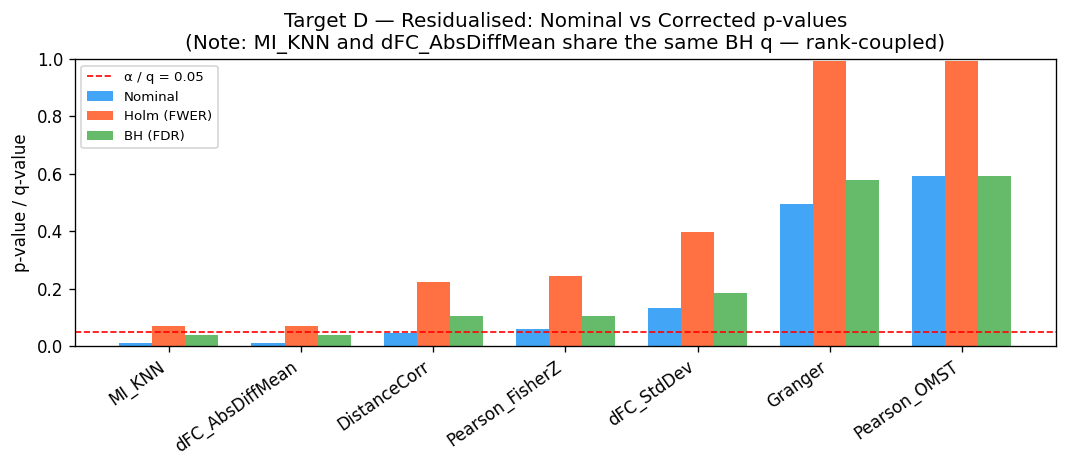

Fig 7 saved.


In [5]:
# Paired bar chart: nominal vs Holm vs BH for Target D resid
d_resid = corr[(corr["target"] == "D") & (corr["condition"] == "resid")].sort_values("nominal_p")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(d_resid))
w = 0.25
ax.bar(x - w, d_resid["nominal_p"], w, label="Nominal", color="#42A5F5")
ax.bar(x,     d_resid["holm_p"],    w, label="Holm (FWER)", color="#FF7043")
ax.bar(x + w, d_resid["bh_fdr_q"],  w, label="BH (FDR)", color="#66BB6A")
ax.axhline(0.05, color="red", ls="--", lw=1, label="α / q = 0.05")
ax.set_xticks(x)
ax.set_xticklabels(d_resid["channel"], rotation=35, ha="right")
ax.set_ylabel("p-value / q-value")
ax.set_title("Target D — Residualised: Nominal vs Corrected p-values\n"
             "(Note: MI_KNN and dFC_AbsDiffMean share the same BH q — rank-coupled)")
ax.legend(fontsize=8)
ax.set_ylim(0, min(1.0, d_resid["holm_p"].max() * 1.3))
fig.tight_layout()
fig.savefig(FIG / "fig7_holm_bh_corrections_D.png", bbox_inches="tight")
fig.savefig(FIG / "fig7_holm_bh_corrections_D.pdf", bbox_inches="tight")
plt.show()
print("Fig 7 saved.")


---
## §3  Incremental value over metadata  (Target D)

Does the connectome add predictive value beyond Age + Sex?

Three models (same 5-fold CV, within-fold PCA):
1. **Metadata only** (Age + Sex -> StandardScaler -> LogReg)
2. **Connectome only** (residualized -> PCA(20) -> LogReg)
3. **Combined** (resid PCA scores + Age + Sex -> LogReg)

Paired bootstrap test on OOF predictions (2 000 resamples).

When distinct channel-specific artifacts are available, this section reports
MI_KNN (ch2) and dFC_AbsDiffMean (ch3) separately. If only the validated
best residualized channel artifact is available, only that channel is reported
to avoid duplicated or mislabeled comparisons.

**Power caveat:** The wide confidence interval on DeltaAUC reflects low
precision at n = 53, not necessarily an absent effect.
See §6 for a quantified power/precision interpretation of this result.

In [6]:
iv_best = _load_json("hardening_D_incremental_value.json")
iv_ch2  = _load_json("hardening_D_incremental_value_ch2.json")
iv_ch3  = _load_json("hardening_D_incremental_value_ch3.json")

# Backward compatibility: use best-channel artifact if explicit file is absent.
if not iv_ch2 and iv_best.get("best_ch") == 2:
    iv_ch2 = iv_best
if not iv_ch3 and iv_best.get("best_ch") == 3:
    iv_ch3 = iv_best

analyses = []
if iv_ch2:
    analyses.append(("MI_KNN (ch2)", iv_ch2))
if iv_ch3:
    analyses.append(("dFC_AbsDiffMean (ch3)", iv_ch3))

# If only one explicit channel is available, report only that analysis (no fake duplication).
if not analyses and iv_best:
    analyses = [(f"{iv_best.get('channel_name', 'Best channel')} (best residualized)", iv_best)]

print("=== Incremental Value — Target D ===")
print()
if len(analyses) == 1:
    print("Reporting the currently available best-channel incremental analysis only.")
    print()

for lbl, iv in analyses:
    print(f"Channel: {lbl}")
    print(f"  Stored channel:        {iv.get('channel_name', 'NA')} (best_ch={iv.get('best_ch', 'NA')})")
    print(f"  Metadata-only AUC:     {iv['auc_metadata']:.4f}")
    print(f"  Connectome-only AUC:   {iv['auc_connectome_resid']:.4f}  95%CI {iv['connectome_ci']}")
    print(f"  Combined AUC:          {iv['auc_combined']:.4f}")
    print(f"  Delta AUC (comb-meta): {iv['delta_comb_vs_meta']:.4f}  p={iv['delta_p']:.3f}  95%CI {iv['delta_ci']}")
    if iv['delta_p'] < 0.05:
        print("  -> Connectome adds significant incremental value.")
    else:
        print("  -> Not significant; CI crosses 0, so this remains non-confirmatory.")
    print()

=== Incremental Value — Target D ===

Reporting the currently available best-channel incremental analysis only.

Channel: dFC_AbsDiffMean (ch3)
  Stored channel:        dFC_AbsDiffMean (best_ch=3)
  Metadata-only AUC:     0.6394
  Connectome-only AUC:   0.7284  95%CI [0.5769, 0.8576]
  Combined AUC:          0.7299
  Delta AUC (comb-meta): 0.0905  p=0.193  95%CI [-0.0952, 0.2856]
  -> Not significant; CI crosses 0, so this remains non-confirmatory.



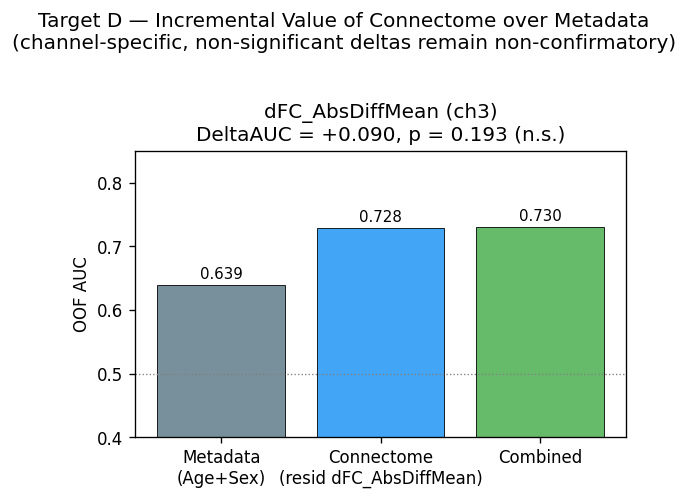

Fig 8 saved.


In [7]:
# Bar chart: metadata vs connectome vs combined
plot_analyses = []
for lbl, iv in [("MI_KNN (ch2)", iv_ch2), ("dFC_AbsDiffMean (ch3)", iv_ch3)]:
    if iv:
        plot_analyses.append((lbl, iv))

if not plot_analyses:
    print("No incremental-value artifacts found for ch2/ch3.")
else:
    fig, axes = plt.subplots(1, len(plot_analyses), figsize=(5 * len(plot_analyses), 4), sharey=True)
    if len(plot_analyses) == 1:
        axes = [axes]

    for ax, (lbl, iv) in zip(axes, plot_analyses):
        aucs = [iv["auc_metadata"], iv["auc_connectome_resid"], iv["auc_combined"]]
        labels = ["Metadata\n(Age+Sex)", f"Connectome\n(resid {iv.get('channel_name', lbl)})", "Combined"]
        colors = ["#78909C", "#42A5F5", "#66BB6A"]
        bars = ax.bar(labels, aucs, color=colors, edgecolor="black", linewidth=0.5)
        ax.axhline(0.5, color="grey", ls=":", lw=0.8)
        for b, v in zip(bars, aucs):
            ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
        ax.set_ylim(0.4, 0.85)
        ax.set_ylabel("OOF AUC")
        delta = iv["delta_comb_vs_meta"]
        p = iv["delta_p"]
        sig_str = "*" if p < 0.05 else "n.s."
        ax.set_title(f"{lbl}\nDeltaAUC = {delta:+.3f}, p = {p:.3f} ({sig_str})")

    fig.suptitle(
        "Target D — Incremental Value of Connectome over Metadata\n"
        "(channel-specific, non-significant deltas remain non-confirmatory)",
        y=1.03,
    )
    fig.tight_layout()
    fig.savefig(FIG / "fig8_incremental_value.png", bbox_inches="tight")
    fig.savefig(FIG / "fig8_incremental_value.pdf", bbox_inches="tight")
    plt.show()
    print("Fig 8 saved.")

---
## §4  Sex-matched subsampling  (Target D, females)

Target D has a significant sex imbalance (23F/6M in FATIGA EXTREMA vs 11F/13M
in NO HAY FATIGA, χ² = 5.03, p = 0.025).  Does the signal persist when sex is
held constant?

**Procedure:** Restrict to females (23 pos / 11 neg).
Subsample 11 from 23 positives → balanced 11 vs 11.
LOOCV with PCA(10) + LogReg on each subsample.  200 repetitions.

**Important caveat:** This analysis is a **descriptive sensitivity check**,
not a definitive falsification.  With n = 22 per sample and balanced
11 vs 11, the study is severely underpowered: even a true AUC = 0.70
would yield < 40% power at α = 0.05.  A near-chance result here means
*unconfirmed within-sex*, not *absent*.  See §6 for quantified precision.


In [8]:
fem = pd.read_csv(OUT / "Tables" / "hardening_D_female_subsampling.csv")
male_path = OUT / "Tables" / "hardening_D_male_subsampling.csv"
male = pd.read_csv(male_path) if male_path.exists() else pd.DataFrame()

print("=== Female sex-matched subsampling (n≈22 per sample) ===")
for ch_name in fem["channel_name"].unique():
    aucs = fem.loc[fem["channel_name"] == ch_name, "auc"].dropna()
    print(f"  {ch_name:20s}  median={aucs.median():.3f}  "
          f"IQR=[{aucs.quantile(0.25):.3f}, {aucs.quantile(0.75):.3f}]  "
          f">0.5: {100*(aucs>0.5).mean():.0f}%")

if len(male) > 0:
    print()
    print("=== Male descriptive (n≈12 per sample, very noisy — descriptive only) ===")
    male_stats = {}
    for ch_name in male["channel_name"].unique():
        aucs = male.loc[male["channel_name"] == ch_name, "auc"].dropna()
        if len(aucs) > 0:
            med = aucs.median()
            male_stats[ch_name] = med
            print(f"  {ch_name:20s}  median={med:.3f}  "
                  f"IQR=[{aucs.quantile(0.25):.3f}, {aucs.quantile(0.75):.3f}]  "
                  f">0.5: {100*(aucs>0.5).mean():.0f}%")

    # Explicitly acknowledge directional divergence while keeping interpretation conservative.
    fem_dfc = fem.loc[fem["channel_name"] == "dFC_AbsDiffMean", "auc"].median()
    male_dfc = male_stats.get("dFC_AbsDiffMean", np.nan)
    if np.isfinite(male_dfc) and np.isfinite(fem_dfc):
        direction = "opposite-direction tendency" if male_dfc < 0.5 <= fem_dfc else "directional instability"
        print()
        print(
            f"Male sensitivity note: dFC_AbsDiffMean shows {direction} "
            f"(male median={male_dfc:.3f} vs female median={fem_dfc:.3f}). "
            "Given the tiny male sample, this is descriptive only and not biologically interpretable."
        )

=== Female sex-matched subsampling (n≈22 per sample) ===
  MI_KNN                median=0.504  IQR=[0.413, 0.595]  >0.5: 54%
  dFC_AbsDiffMean       median=0.550  IQR=[0.438, 0.638]  >0.5: 62%
  DistanceCorr          median=0.471  IQR=[0.386, 0.587]  >0.5: 44%

=== Male descriptive (n≈12 per sample, very noisy — descriptive only) ===
  MI_KNN                median=0.556  IQR=[0.368, 0.722]  >0.5: 56%
  dFC_AbsDiffMean       median=0.417  IQR=[0.285, 0.528]  >0.5: 28%
  DistanceCorr          median=0.583  IQR=[0.417, 0.750]  >0.5: 58%

Male sensitivity note: dFC_AbsDiffMean shows opposite-direction tendency (male median=0.417 vs female median=0.550). Given the tiny male sample, this is descriptive only and not biologically interpretable.


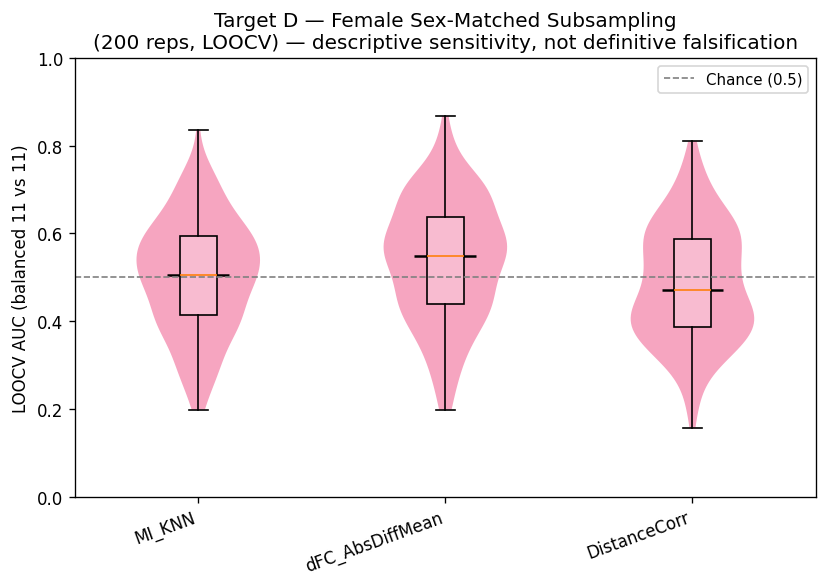

Fig 9 saved.


In [9]:
channels = fem["channel_name"].unique()
fig, ax = plt.subplots(figsize=(7, 5))

positions = np.arange(len(channels))
data = [fem.loc[fem["channel_name"] == ch, "auc"].dropna().values for ch in channels]
vp = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
for body in vp["bodies"]:
    body.set_facecolor("#E91E63")
    body.set_alpha(0.4)
vp["cmedians"].set_color("black")

# Overlay boxplot
bp = ax.boxplot(data, positions=positions, widths=0.15, patch_artist=True,
                showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#F8BBD0")
    patch.set_edgecolor("black")

ax.axhline(0.5, color="grey", ls="--", lw=1, label="Chance (0.5)")
ax.set_xticks(positions)
ax.set_xticklabels(channels, rotation=20, ha="right")
ax.set_ylabel("LOOCV AUC (balanced 11 vs 11)")
ax.set_title("Target D — Female Sex-Matched Subsampling\n"
             "(200 reps, LOOCV) — descriptive sensitivity, not definitive falsification")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0.0, 1.0)
fig.tight_layout()
fig.savefig(FIG / "fig9_sex_matched_subsampling.png", bbox_inches="tight")
fig.savefig(FIG / "fig9_sex_matched_subsampling.pdf", bbox_inches="tight")
plt.show()
print("Fig 9 saved.")


---
## §5  Metadata decomposition  (Target D)

Is the Age+Sex metadata AUC driven primarily by sex or by age?

This matters because the sex imbalance (χ² p = 0.025) is the most
plausible metadata confound for Target D.  If sex alone explains most
of the metadata AUC, and if sex is also a likely driver of the
connectome signal (see §4), then both the metadata model and the
connectome model may be capturing sex differences rather than fatigue biology.

Three models (same 5-fold CV):
- **Age only** — logistic regression on Age alone
- **Sex only** — logistic regression on Sex alone  
- **Age + Sex** — logistic regression on both

Permutation p-value vs. chance and bootstrap 95% CI are reported for each.


In [10]:
meta_d = _load_json("hardening_D_metadata_decomposition.json")

if meta_d:
    print("=== Metadata Decomposition — Target D ===")
    print()
    for name in ["age_only", "sex_only", "age_sex"]:
        r = meta_d.get(name, {})
        if r:
            sig = "*" if r["perm_p"] < 0.05 else "n.s."
            print(f"  {name:12s}  AUC={r['auc']:.4f}  "
                  f"95%CI [{r['ci_95'][0]:.4f}, {r['ci_95'][1]:.4f}]  "
                  f"perm_p={r['perm_p']:.4f} ({sig})")
    print()

    auc_sex = meta_d.get("sex_only", {}).get("auc", 0)
    p_sex = meta_d.get("sex_only", {}).get("perm_p", 1)
    auc_age = meta_d.get("age_only", {}).get("auc", 0)
    p_age = meta_d.get("age_only", {}).get("perm_p", 1)
    auc_as  = meta_d.get("age_sex",  {}).get("auc", 0)

    if auc_sex > auc_age:
        print(
            f"  -> Sex has the larger point-estimate AUC than age in this cohort "
            f"(sex={auc_sex:.4f}, age={auc_age:.4f}), but neither individual model "
            f"is significant on its own (sex p={p_sex:.4f}, age p={p_age:.4f})."
        )
        print(f"     Age+Sex reaches AUC={auc_as:.4f}; interpretation remains confound-sensitive.")
    else:
        print(
            f"  -> Age has the larger point-estimate AUC than sex in this cohort "
            f"(age={auc_age:.4f}, sex={auc_sex:.4f}), but neither individual model "
            f"is significant on its own (age p={p_age:.4f}, sex p={p_sex:.4f})."
        )
        print(f"     Age+Sex reaches AUC={auc_as:.4f}; interpretation remains confound-sensitive.")
else:
    print("Metadata decomposition file not found. Rerun run_fatigue_hardening.py.")

=== Metadata Decomposition — Target D ===

  age_only      AUC=0.5503  95%CI [0.3906, 0.7058]  perm_p=0.2398 (n.s.)
  sex_only      AUC=0.6020  95%CI [0.4409, 0.7622]  perm_p=0.1139 (n.s.)
  age_sex       AUC=0.6394  95%CI [0.4787, 0.7918]  perm_p=0.0440 (*)

  -> Sex has the larger point-estimate AUC than age in this cohort (sex=0.6020, age=0.5503), but neither individual model is significant on its own (sex p=0.1139, age p=0.2398).
     Age+Sex reaches AUC=0.6394; interpretation remains confound-sensitive.


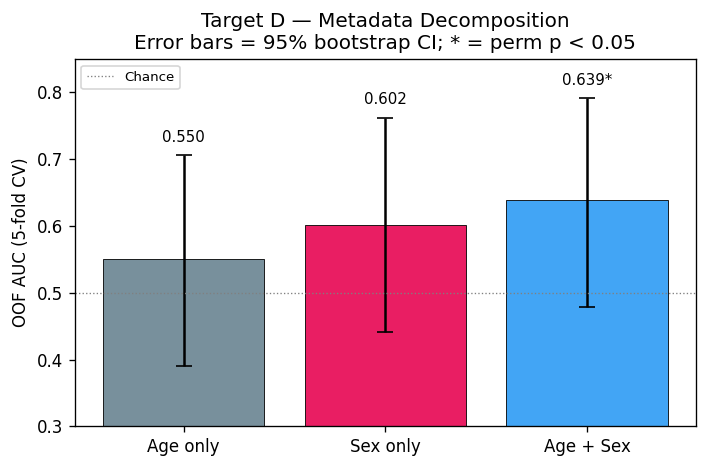

Fig 10 saved.


In [11]:
if meta_d:
    names  = ["age_only", "sex_only", "age_sex"]
    labels = ["Age only", "Sex only", "Age + Sex"]
    aucs   = [meta_d[n]["auc"] for n in names]
    ci_lo  = [meta_d[n]["ci_95"][0] for n in names]
    ci_hi  = [meta_d[n]["ci_95"][1] for n in names]
    pvals  = [meta_d[n]["perm_p"] for n in names]

    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(names))
    bars = ax.bar(x, aucs,
                  yerr=[np.array(aucs)-np.array(ci_lo), np.array(ci_hi)-np.array(aucs)],
                  capsize=5, color=["#78909C", "#E91E63", "#42A5F5"],
                  edgecolor="black", linewidth=0.5)
    ax.axhline(0.5, color="grey", ls=":", lw=0.8, label="Chance")
    for i, (b, p, a) in enumerate(zip(bars, pvals, aucs)):
        sig = "*" if p < 0.05 else ""
        ax.text(b.get_x() + b.get_width()/2, a + (np.array(ci_hi)-np.array(aucs))[i] + 0.02,
                f"{a:.3f}{sig}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("OOF AUC (5-fold CV)")
    ax.set_ylim(0.3, 0.85)
    ax.set_title("Target D — Metadata Decomposition\n"
                 "Error bars = 95% bootstrap CI; * = perm p < 0.05")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / "fig10_metadata_decomposition.png", bbox_inches="tight")
    fig.savefig(FIG / "fig10_metadata_decomposition.pdf", bbox_inches="tight")
    plt.show()
    print("Fig 10 saved.")


---
## §6  Power / precision analysis  (Target D)

This section separates three different inferential questions that can be
confused if only one power number is shown.

1. **AUC > 0.5 tests** (connectome-only or metadata-only discrimination)
2. **Incremental-value test** used in the verdict
   (DeltaAUC = AUC(combined) - AUC(metadata))
3. **Within-sex female sensitivity** (descriptive robustness check)

The first question can be reasonably powered for large AUC effects at n=53.
That does **not** imply good power for DeltaAUC over metadata, and it does
**not** imply adequate power for female-only sensitivity subsamples.

The verdict-relevant negatives are therefore interpreted as:
- DeltaAUC non-significant: low precision / low-to-moderate power,
- Female-only near-chance: low-power descriptive result,
not definitive evidence of absence.

| Verdict-relevant negative | Approx power/precision statement | Practical implication |
|---------------------------|----------------------------------|----------------------|
| DeltaAUC (combined-meta) non-significant | Approx power ~0.24 from observed effect and CI width | Underpowered for confirmatory incremental-value claims |
| Female-only sensitivity near chance | n=22 balanced subsamples with broad channel distributions | Descriptive only; cannot adjudicate within-sex absence |

In [12]:
power_d = _load_json("hardening_D_power_analysis.json")

# Helpers for normal CDF without extra dependencies.
def _norm_cdf(z):
    return 0.5 * (1.0 + np.math.erf(z / np.sqrt(2.0)))

if power_d:
    print("=== Power Analysis — Target D ===")
    print()
    print("A) AUC > 0.5 style tests (not the same as incremental-value power)")
    print(f"  {'Model':<30s}  {'AUC':>6s}  {'SE':>6s}  {'Effect':>7s}  {'Power@n':>8s}  {'n for 80%':>10s}")
    print("-" * 92)
    order = ["best_resid_connectome", "metadata_age_sex", "sex_only", "age_only", "combined"]
    labels = {
        "best_resid_connectome": "Best resid connectome",
        "metadata_age_sex":      "Metadata (Age+Sex)",
        "sex_only":              "Sex only",
        "age_only":              "Age only",
        "combined":              "Combined (conn+meta)",
    }
    for key in order:
        if key not in power_d:
            continue
        r = power_d[key]
        n80 = r.get("n_for_80pct_power_approx")
        n80_str = str(n80) if n80 is not None else "—"
        print(f"  {labels.get(key, key):<30s}  {r['auc']:>6.4f}  {r['bootstrap_se']:>6.4f}  "
              f"{r['effect_auc_minus_chance']:>7.4f}  {r['power_at_current_n']:>8.3f}  {n80_str:>10s}")
    print()

    print("B) Verdict-relevant incremental value (DeltaAUC = combined - metadata)")
    iv_best = _load_json("hardening_D_incremental_value.json")
    if iv_best:
        delta = float(iv_best["delta_comb_vs_meta"])
        ci_lo, ci_hi = [float(v) for v in iv_best["delta_ci"]]
        # Approximate SE from 95% CI half-width.
        se_delta = (ci_hi - ci_lo) / (2 * 1.96) if ci_hi > ci_lo else np.nan
        z_alpha = 1.6448536269514722  # one-sided alpha=0.05
        if np.isfinite(se_delta) and se_delta > 0:
            power_delta = _norm_cdf(delta / se_delta - z_alpha)
            print(f"  DeltaAUC observed = {delta:+.4f}  95%CI [{ci_lo:.4f}, {ci_hi:.4f}]")
            print(f"  Approx SE(DeltaAUC) ~ {se_delta:.4f}; approx power ~ {power_delta:.3f}")
            print("  Interpretation: high connectome-only power does not imply well-powered incremental-value testing.")
        else:
            print("  Could not derive approximate DeltaAUC precision from artifact CI.")
    else:
        print("  Missing hardening_D_incremental_value.json")
    print()

    print("C) Female-only sensitivity precision (descriptive, low-power)")
    fem_path = OUT / "Tables" / "hardening_D_female_subsampling.csv"
    if fem_path.exists():
        fem = pd.read_csv(fem_path)
        # Use dFC_AbsDiffMean because it is the strongest residualized channel in Target D.
        aucs_f = fem.loc[fem["channel_name"] == "dFC_AbsDiffMean", "auc"].dropna()
        if len(aucs_f) > 0:
            med_f = float(aucs_f.median())
            q1_f = float(aucs_f.quantile(0.25))
            q3_f = float(aucs_f.quantile(0.75))
            gt50 = float((aucs_f > 0.5).mean())
            n_pos = n_neg = 11
            q1 = med_f / (2 - med_f)
            q2 = 2 * med_f * med_f / (1 + med_f)
            se_auc = np.sqrt((med_f * (1 - med_f) + (n_pos - 1) * (q1 - med_f * med_f) + (n_neg - 1) * (q2 - med_f * med_f)) / (n_pos * n_neg))
            z_alpha = 1.6448536269514722
            power_f = _norm_cdf((med_f - 0.5) / se_auc - z_alpha) if se_auc > 0 else np.nan
            print(f"  dFC_AbsDiffMean female subsampling: median={med_f:.3f}, IQR=[{q1_f:.3f}, {q3_f:.3f}], P(AUC>0.5)={gt50:.3f}")
            if np.isfinite(power_f):
                print(f"  Approx power for AUC>0.5 at n=22 (11 vs 11) ~ {power_f:.3f} (rough Hanley-McNeil approximation)")
            print("  Interpretation: descriptive sensitivity only; inadequate for confirmatory within-sex claims.")
        else:
            print("  Female subsampling file found but dFC_AbsDiffMean rows are missing.")
    else:
        print("  Female subsampling file not found.")
else:
    print("Power analysis file not found. Rerun run_fatigue_hardening.py.")

=== Power Analysis — Target D ===

A) AUC > 0.5 style tests (not the same as incremental-value power)
  Model                              AUC      SE   Effect   Power@n   n for 80%
--------------------------------------------------------------------------------------------
  Best resid connectome           0.7284  0.0737   0.2284     0.927          34
  Metadata (Age+Sex)              0.6394  0.0804   0.1394     0.535         109
  Sex only                        0.6020  0.0807   0.1020     0.351         205
  Age only                        0.5503  0.0786   0.0503     0.157         801
  Combined (conn+meta)            0.7313  0.0748   0.2313     0.926          34

B) Verdict-relevant incremental value (DeltaAUC = combined - metadata)
  DeltaAUC observed = +0.0920  95%CI [-0.0934, 0.2857]
  Approx SE(DeltaAUC) ~ 0.0967; approx power ~ 0.244
  Interpretation: high connectome-only power does not imply well-powered incremental-value testing.

C) Female-only sensitivity precision (descri

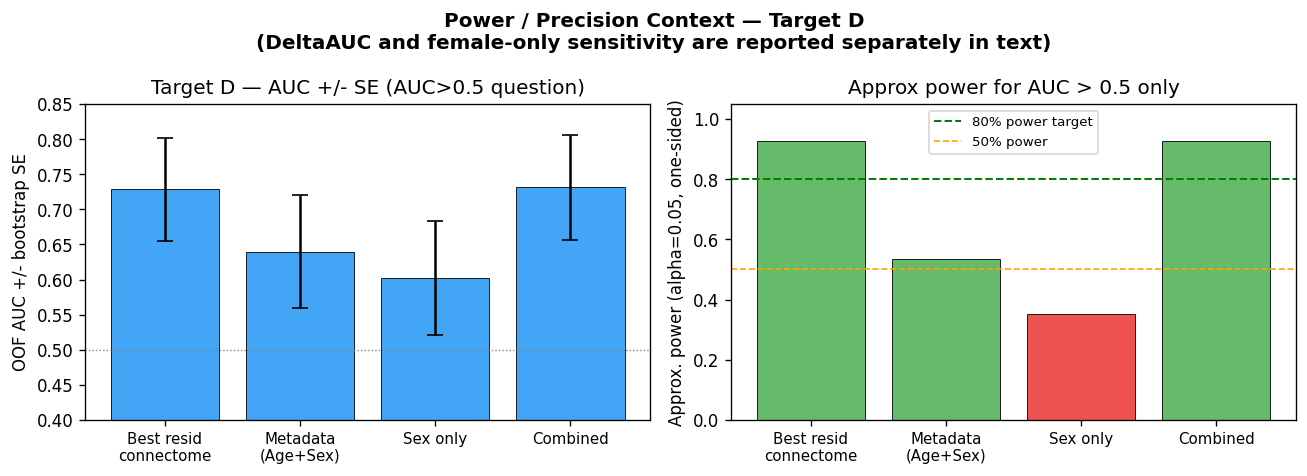

Fig 11 saved.


In [13]:
if power_d:
    order = ["best_resid_connectome", "metadata_age_sex", "sex_only", "combined"]
    labels_plot = ["Best resid\nconnectome", "Metadata\n(Age+Sex)", "Sex only", "Combined"]
    aucs_p = [power_d[k]["auc"] for k in order if k in power_d]
    ses_p  = [power_d[k]["bootstrap_se"] for k in order if k in power_d]
    pwrs_p = [power_d[k]["power_at_current_n"] for k in order if k in power_d]
    lbs_p  = [labels_plot[i] for i, k in enumerate(order) if k in power_d]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # AUC with SE bars (AUC > 0.5 style effects)
    ax = axes[0]
    x = np.arange(len(aucs_p))
    ax.bar(x, aucs_p, yerr=ses_p, capsize=5, color="#42A5F5", edgecolor="black", linewidth=0.5)
    ax.axhline(0.5, color="grey", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(lbs_p, fontsize=9)
    ax.set_ylabel("OOF AUC +/- bootstrap SE")
    ax.set_title("Target D — AUC +/- SE (AUC>0.5 question)")
    ax.set_ylim(0.4, 0.85)

    # Power for AUC > 0.5 (not DeltaAUC power)
    ax = axes[1]
    colors_pw = ["#66BB6A" if p >= 0.5 else "#EF5350" for p in pwrs_p]
    ax.bar(x, pwrs_p, color=colors_pw, edgecolor="black", linewidth=0.5)
    ax.axhline(0.80, color="green", ls="--", lw=1.2, label="80% power target")
    ax.axhline(0.50, color="orange", ls="--", lw=1.0, label="50% power")
    ax.set_xticks(x)
    ax.set_xticklabels(lbs_p, fontsize=9)
    ax.set_ylabel("Approx. power (alpha=0.05, one-sided)")
    ax.set_title("Approx power for AUC > 0.5 only")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

    fig.suptitle(
        "Power / Precision Context — Target D\n"
        "(DeltaAUC and female-only sensitivity are reported separately in text)",
        fontweight="bold",
    )
    fig.tight_layout()
    fig.savefig(FIG / "fig11_power_analysis.png", bbox_inches="tight")
    fig.savefig(FIG / "fig11_power_analysis.pdf", bbox_inches="tight")
    plt.show()
    print("Fig 11 saved.")

---
## §7  Hardened Verdict

### Target D  (COVID-only, FATIGA EXTREMA vs NO HAY FATIGA)

| Test | Result | Interpretation |
|------|--------|---------------|
| Max-perm omnibus FWER (within-fold PCA, 7 channels) | best resid AUC = 0.7284, corrected p = 0.028 | **PASS** at alpha=0.05 (family-level omnibus evidence) |
| Holm-Bonferroni per-channel FWER | MI_KNN p = 0.06993, dFC_AbsDiffMean p = 0.06993 | **FAIL** at alpha=0.05 for individual channels |
| Benjamini-Hochberg FDR | MI_KNN q = 0.03846, dFC_AbsDiffMean q = 0.03846 (rank-coupled) | Exploratory FDR signal only |
| Incremental value over Age+Sex | DeltaAUC = +0.0920, p = 0.187, 95%CI [-0.0934, 0.2857] | Not significant; criterion (c) fails |
| Female sex-matched sensitivity | dFC median AUC ~0.545 (IQR ~0.438-0.636) in repeated 11v11 subsamples | Descriptive only; low precision, criterion (b) not confirmed |
| Metadata decomposition | Sex-only AUC (0.6020) > Age-only AUC (0.5503), but both n.s. alone | Confound structure remains plausible |

**FWER clarification:**
The channel-selection-corrected **max-permutation omnibus test passes**, while
the **per-channel Holm FWER test does not**. These are different procedures
with different sensitivities: max-statistic omnibus across channels vs
step-down per-channel correction.

**Target D conclusion:** Some family-level evidence exists under omnibus
max-perm, but channel-specific confirmation and robustness criteria are not met.
Therefore Target D remains **non-confirmatory**.

### Target E  (all groups, shortcut audit — not fatigue evidence)

| Test | Result | Interpretation |
|------|--------|---------------|
| Max-perm corrected (within-fold) | raw corrected p = 0.019, resid corrected p = 0.009 | Strong separability signal |
| Group confound | chi2 = 18.19, p < 0.0001 | Severe COVID/CONTROL shortcut threat |

**Target E conclusion:** This is a falsification/shortcut audit signal and is
explicitly demoted from fatigue interpretation.

### Overall Hardened Verdict

> ### INDETERMINATE
>
> There is **some** family-level evidence in Target D under omnibus
> channel-selection correction (max-perm p = 0.028), but the result remains
> **non-confirmatory** because key criteria fail:
> - Per-channel Holm FWER does not survive (MI_KNN and dFC_AbsDiffMean p ~ 0.070).
> - Incremental value over metadata is not significant (DeltaAUC p = 0.187).
> - Within-sex sensitivity is low-power and descriptive, not confirmatory.
> - Sex/confound entanglement remains plausible.
>
> Target E is treated as a shortcut audit only and does not support fatigue claims.
> This verdict is aligned with `04_a`: **INDETERMINATE**.

In [14]:
from IPython.display import display, HTML

display(HTML(
    "<div style='background:#f8d7da;border:2px solid #842029;padding:16px;"
    "border-radius:8px;margin:12px 0;text-align:center'>"
    "<h2 style='color:#842029;margin:0 0 8px 0'>HARDENED VERDICT</h2>"
    "<h3 style='color:#842029;margin:0'>INDETERMINATE</h3>"
    "<p style='margin:8px 0 0 0'>"
    "Target D: max-perm omnibus FWER passes (corrected p = 0.028), but "
    "per-channel Holm FWER does not (p ~ 0.070), incremental value over metadata is n.s., "
    "and within-sex sensitivity remains low-power/descriptive.<br>"
    "Target E remains a shortcut/falsification audit, not supportive fatigue evidence.<br>"
    "Result aligned with <code>04_a</code> verdict."
    "</p></div>"
))